# Feature Selection Timeline By Month

Batch visualization for **all crops** and **all horizons** using HAR expanding feature selection for the full feature set `har_endo_exo_climate_news_macro`.

The notebook:
- scans benchmark outputs under `data/benchmark/*/har/mean`
- keeps only `model_type` in `{lasso_expanding, bsr_expanding}`
- keeps only `feature_set == har_endo_exo_climate_news_macro`
- aggregates daily selections to **monthly** selected/not-selected status
- creates one **2 x 3** figure for each `(crop, model_type)` pair
- saves **6 total plots**: 3 crops × 2 models


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

BENCHMARK_ROOT = PROJECT_ROOT / 'data' / 'benchmark'
OUTPUT_ROOT = BENCHMARK_ROOT / 'plots' / 'feature_selection_monthly'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Benchmark root: {BENCHMARK_ROOT}')
print(f'Output root: {OUTPUT_ROOT}')


Project root: /Users/arshia/Projects/Papers/FinancialAI/Volf
Benchmark root: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark
Output root: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/feature_selection_monthly


In [3]:
def safe_name(value: str) -> str:
    cleaned = re.sub(r'[^A-Za-z0-9._-]+', '_', str(value).strip())
    return cleaned.strip('_') or 'unknown'


def discover_har_summaries(benchmark_root: Path) -> pd.DataFrame:
    rows: list[dict] = []
    for csv_path in sorted(benchmark_root.glob('*/har/mean/target_horizon_*/har.csv')):
        crop = csv_path.parts[-5]
        horizon = int(csv_path.parent.name.split('_')[-1])
        frame = pd.read_csv(csv_path)
        if frame.empty:
            continue
        frame = frame.copy()
        frame['crop'] = crop
        frame['target_horizon'] = frame.get('target_horizon', horizon)
        frame['summary_path'] = str(csv_path)
        rows.extend(frame.to_dict(orient='records'))

    if not rows:
        raise FileNotFoundError(f'No HAR summary files found under {benchmark_root}')
    out = pd.DataFrame(rows)
    out['target_horizon'] = out['target_horizon'].astype(int)
    return out


summary_df = discover_har_summaries(BENCHMARK_ROOT)
TARGET_MODEL_TYPES = ['lasso_expanding', 'bsr_expanding']
TARGET_FEATURE_SET = 'har_endo_exo_climate_news_macro'
TARGET_HORIZON_ORDER = [1, 4, 8, 12, 16]

selected_runs_df = (
    summary_df.loc[
        summary_df['model_type'].astype(str).isin(TARGET_MODEL_TYPES)
        & summary_df['feature_set'].astype(str).eq(TARGET_FEATURE_SET)
    ]
    .sort_values(['crop', 'model_type', 'target_horizon', 'test_r2'], ascending=[True, True, True, False])
    .reset_index(drop=True)
)

print(f'Total HAR rows: {len(summary_df):,}')
print(f'Matching expanding rows: {len(selected_runs_df):,}')
display(selected_runs_df[['crop', 'target_horizon', 'model_type', 'feature_set', 'test_r2', 'n_selected']].head(20))


Total HAR rows: 900
Matching expanding rows: 30


,crop,target_horizon,model_type,feature_set,test_r2,n_selected
0,corn,1,bsr_expanding,har_endo_exo_climate_news_macro,0.522745,17
1,corn,4,bsr_expanding,har_endo_exo_climate_news_macro,0.518357,29
2,corn,8,bsr_expanding,har_endo_exo_climate_news_macro,0.427653,28
3,corn,12,bsr_expanding,har_endo_exo_climate_news_macro,0.370176,30
4,corn,16,bsr_expanding,har_endo_exo_climate_news_macro,0.284664,35
5,corn,1,lasso_expanding,har_endo_exo_climate_news_macro,0.516621,37
6,corn,4,lasso_expanding,har_endo_exo_climate_news_macro,0.535164,40
7,corn,8,lasso_expanding,har_endo_exo_climate_news_macro,0.422695,44
8,corn,12,lasso_expanding,har_endo_exo_climate_news_macro,0.372884,46
9,corn,16,lasso_expanding,har_endo_exo_climate_news_macro,0.306955,46


In [4]:
def checkpoint_dir_from_row(benchmark_root: Path, row: pd.Series) -> Path:
    return (
        benchmark_root
        / str(row['crop'])
        / 'har'
        / 'mean'
        / f"target_horizon_{int(row['target_horizon'])}"
        / 'checkpoints'
        / f"{safe_name(row['model_type'])}__{safe_name(row['feature_set'])}"
    )


def load_selection_artifacts(benchmark_root: Path, row: pd.Series) -> tuple[Path, pd.DataFrame, dict]:
    ckpt_dir = checkpoint_dir_from_row(benchmark_root, row)
    per_window_path = ckpt_dir / 'per_window_selection.csv'
    selection_info_path = ckpt_dir / 'selection_info.json'

    if not per_window_path.exists():
        raise FileNotFoundError(f'Missing file: {per_window_path}')

    per_window_df = pd.read_csv(per_window_path)
    selection_info = {}
    if selection_info_path.exists():
        selection_info = json.loads(selection_info_path.read_text(encoding='utf-8'))

    return ckpt_dir, per_window_df, selection_info


def explode_selection_by_day(per_window_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []

    for row in per_window_df.to_dict(orient='records'):
        selected_feature = row.get('selected_feature')
        if pd.isna(selected_feature):
            continue

        raw_test_dates = row.get('test_dates')
        if isinstance(raw_test_dates, str) and raw_test_dates.strip():
            dates = [pd.to_datetime(item) for item in raw_test_dates.split('|') if item]
        else:
            fallback = row.get('test_start_date') or row.get('test_end_date')
            dates = [pd.to_datetime(fallback)] if pd.notna(fallback) else []

        for date in dates:
            rows.append(
                {
                    'date': pd.to_datetime(date).normalize(),
                    'feature': str(selected_feature),
                    'window_id': int(row['window_id']),
                    'selected': 1,
                    'selection_method': row.get('selection_method'),
                    'selection_reused': bool(row.get('selection_reused', False)),
                }
            )

    if not rows:
        raise ValueError('Could not create any daily feature-selection rows.')

    selected_df = pd.DataFrame(rows).drop_duplicates(subset=['date', 'feature'], keep='last')
    all_dates = pd.Index(sorted(selected_df['date'].unique()), name='date')
    all_features = pd.Index(sorted(selected_df['feature'].unique()), name='feature')
    dense_index = pd.MultiIndex.from_product([all_dates, all_features], names=['date', 'feature'])

    dense_df = (
        selected_df.set_index(['date', 'feature'])[['selected', 'window_id', 'selection_method', 'selection_reused']]
        .reindex(dense_index)
        .reset_index()
    )
    dense_df['selected'] = dense_df['selected'].fillna(0).astype(int)
    dense_df['month'] = dense_df['date'].dt.to_period('M').dt.to_timestamp()
    dense_df['selected_label'] = dense_df['selected'].map({1: 'selected', 0: 'not selected'})
    return dense_df.sort_values(['feature', 'date']).reset_index(drop=True)


def aggregate_selection_by_month(selection_daily_df: pd.DataFrame) -> pd.DataFrame:
    monthly_df = (
        selection_daily_df.groupby(['month', 'feature'], as_index=False)
        .agg(
            selected_days=('selected', 'sum'),
            total_days=('selected', 'size'),
            reused_any=('selection_reused', 'max'),
        )
    )
    monthly_df['selected_share'] = monthly_df['selected_days'] / monthly_df['total_days']
    monthly_df['selected'] = (monthly_df['selected_days'] > 0).astype(int)
    monthly_df['selected_label'] = monthly_df['selected'].map({1: 'selected', 0: 'not selected'})
    return monthly_df.sort_values(['feature', 'month']).reset_index(drop=True)


In [5]:
def build_monthly_heatmap(
    monthly_df: pd.DataFrame,
    top_n_features: int | None = None,
) -> tuple[pd.DataFrame, pd.Series]:
    plot_df = monthly_df.copy()
    feature_order = (
        plot_df.groupby('feature', as_index=False)['selected_share']
        .mean()
        .sort_values(['selected_share', 'feature'], ascending=[False, True])
    )

    if top_n_features is not None:
        feature_order = feature_order.head(top_n_features)
        plot_df = plot_df.loc[plot_df['feature'].isin(feature_order['feature'])].copy()

    ordered_features = feature_order['feature'].tolist()
    heatmap_df = (
        plot_df.pivot(index='feature', columns='month', values='selected')
        .reindex(ordered_features)
        .sort_index(axis=1)
    )
    feature_percent = (
        plot_df.groupby('feature')['selected_share']
        .mean()
        .reindex(ordered_features)
        .fillna(0.0)
        .mul(100.0)
    )
    return heatmap_df, feature_percent


def plot_crop_horizon_grid(
    crop_runs_df: pd.DataFrame,
    monthly_lookup: dict[tuple[str, int, str], pd.DataFrame],
    *,
    crop: str,
    model_type: str,
    output_path: Path | None = None,
    top_n_features: int | None = None,
) -> None:
    horizons = [h for h in TARGET_HORIZON_ORDER if h in set(crop_runs_df['target_horizon'])]
    nrows, ncols = 3, 2
    fig = plt.figure(figsize=(30, 18))
    outer = fig.add_gridspec(nrows=nrows, ncols=ncols, wspace=0.25, hspace=0.5)
    fig.subplots_adjust(right=0.90)

    cmap = sns.color_palette(['#d62728', '#2ca02c'])
    cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.64])
    colorbar_source = None

    for panel_idx in range(nrows * ncols):
        row_idx = panel_idx // ncols
        col_idx = panel_idx % ncols
        panel_spec = outer[row_idx, col_idx].subgridspec(1, 2, width_ratios=[4.8, 1.4], wspace=0.05)
        heat_ax = fig.add_subplot(panel_spec[0, 0])
        bar_ax = fig.add_subplot(panel_spec[0, 1])

        if panel_idx >= len(TARGET_HORIZON_ORDER):
            heat_ax.axis('off')
            bar_ax.axis('off')
            continue

        horizon = TARGET_HORIZON_ORDER[panel_idx]
        horizon_runs = crop_runs_df.loc[crop_runs_df['target_horizon'].eq(horizon)].copy()
        if horizon_runs.empty:
            heat_ax.axis('off')
            bar_ax.axis('off')
            heat_ax.set_title(f'H={horizon} | missing', fontsize=11)
            continue

        best_row = horizon_runs.sort_values(['test_r2'], ascending=[False]).iloc[0]
        lookup_key = (crop, int(horizon), str(best_row['model_type']))
        monthly_df = monthly_lookup[lookup_key]
        heatmap_df, feature_percent = build_monthly_heatmap(monthly_df, top_n_features=top_n_features)

        show_cbar = colorbar_source is None
        hm = sns.heatmap(
            heatmap_df,
            cmap=cmap,
            vmin=0,
            vmax=1,
            cbar=show_cbar,
            cbar_ax=cbar_ax if show_cbar else None,
            linewidths=0.05,
            linecolor='lightgray',
            ax=heat_ax,
        )
        if show_cbar:
            colorbar_source = hm
            colorbar = hm.collections[0].colorbar
            colorbar.set_ticks([0.25, 0.75])
            colorbar.set_ticklabels(['not selected', 'selected'])

        heat_ax.set_title(
            f"H={int(horizon)}",
            fontsize=11,
        )
        heat_ax.set_xlabel('Year')
        heat_ax.set_ylabel('Feature')
        year_positions: list[float] = []
        year_labels: list[str] = []
        last_year: int | None = None
        for index, col in enumerate(heatmap_df.columns):
            year = pd.Timestamp(col).year
            if year != last_year:
                year_positions.append(index + 0.5)
                year_labels.append(str(year))
                last_year = year
        heat_ax.set_xticks(year_positions)
        heat_ax.set_xticklabels(
            year_labels,
            rotation=0,
            ha='center',
            fontsize=8,
        )
        heat_ax.set_yticklabels(heat_ax.get_yticklabels(), rotation=0, fontsize=8)

        y_positions = [index + 0.5 for index in range(len(feature_percent.index))]
        bar_ax.barh(y_positions, feature_percent.values, color='#4c78a8', height=0.8)
        bar_ax.set_ylim(heat_ax.get_ylim())
        bar_ax.set_xlim(0, 100)
        bar_ax.set_xlabel('% selected', fontsize=8)
        bar_ax.set_xticks([0, 50, 100])
        bar_ax.tick_params(axis='x', labelsize=8)
        bar_ax.tick_params(axis='y', left=False, labelleft=False)
        for spine in ['top', 'right', 'left']:
            bar_ax.spines[spine].set_visible(False)
        bar_ax.grid(axis='x', linestyle='--', alpha=0.3)

    fig.suptitle(
        f"{crop.capitalize()} monthly feature selection | {model_type} | full feature set",
        fontsize=16,
        y=0.98,
    )

    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=220, bbox_inches='tight')

    plt.show()
    plt.close(fig)


## Batch export settings

In [6]:
SAVE_PLOTS = True
TOP_N_FEATURES = None

runs_to_process = selected_runs_df.copy()
print(f'Runs to process: {len(runs_to_process):,}')
display(runs_to_process[['crop', 'target_horizon', 'model_type', 'feature_set', 'test_r2']].head(20))


Runs to process: 30


,crop,target_horizon,model_type,feature_set,test_r2
0,corn,1,bsr_expanding,har_endo_exo_climate_news_macro,0.522745
1,corn,4,bsr_expanding,har_endo_exo_climate_news_macro,0.518357
2,corn,8,bsr_expanding,har_endo_exo_climate_news_macro,0.427653
3,corn,12,bsr_expanding,har_endo_exo_climate_news_macro,0.370176
4,corn,16,bsr_expanding,har_endo_exo_climate_news_macro,0.284664
5,corn,1,lasso_expanding,har_endo_exo_climate_news_macro,0.516621
6,corn,4,lasso_expanding,har_endo_exo_climate_news_macro,0.535164
7,corn,8,lasso_expanding,har_endo_exo_climate_news_macro,0.422695
8,corn,12,lasso_expanding,har_endo_exo_climate_news_macro,0.372884
9,corn,16,lasso_expanding,har_endo_exo_climate_news_macro,0.306955


In [7]:
monthly_lookup: dict[tuple[str, int, str], pd.DataFrame] = {}
failed_runs: list[dict] = []

for _, row in runs_to_process.iterrows():
    crop = str(row['crop'])
    horizon = int(row['target_horizon'])
    model_type = str(row['model_type'])

    try:
        checkpoint_dir, per_window_df, selection_info = load_selection_artifacts(BENCHMARK_ROOT, row)
        selection_daily_df = explode_selection_by_day(per_window_df)
        monthly_df = aggregate_selection_by_month(selection_daily_df)
        monthly_lookup[(crop, horizon, model_type)] = monthly_df
    except Exception as exc:
        failed_runs.append(
            {
                'crop': crop,
                'target_horizon': horizon,
                'model_type': model_type,
                'feature_set': str(row['feature_set']),
                'error': str(exc),
            }
        )

failed_df = pd.DataFrame(failed_runs)
print(f'Prepared monthly selections for {len(monthly_lookup):,} crop/horizon/model runs')
if not failed_df.empty:
    display(failed_df)


Prepared monthly selections for 30 crop/horizon/model runs


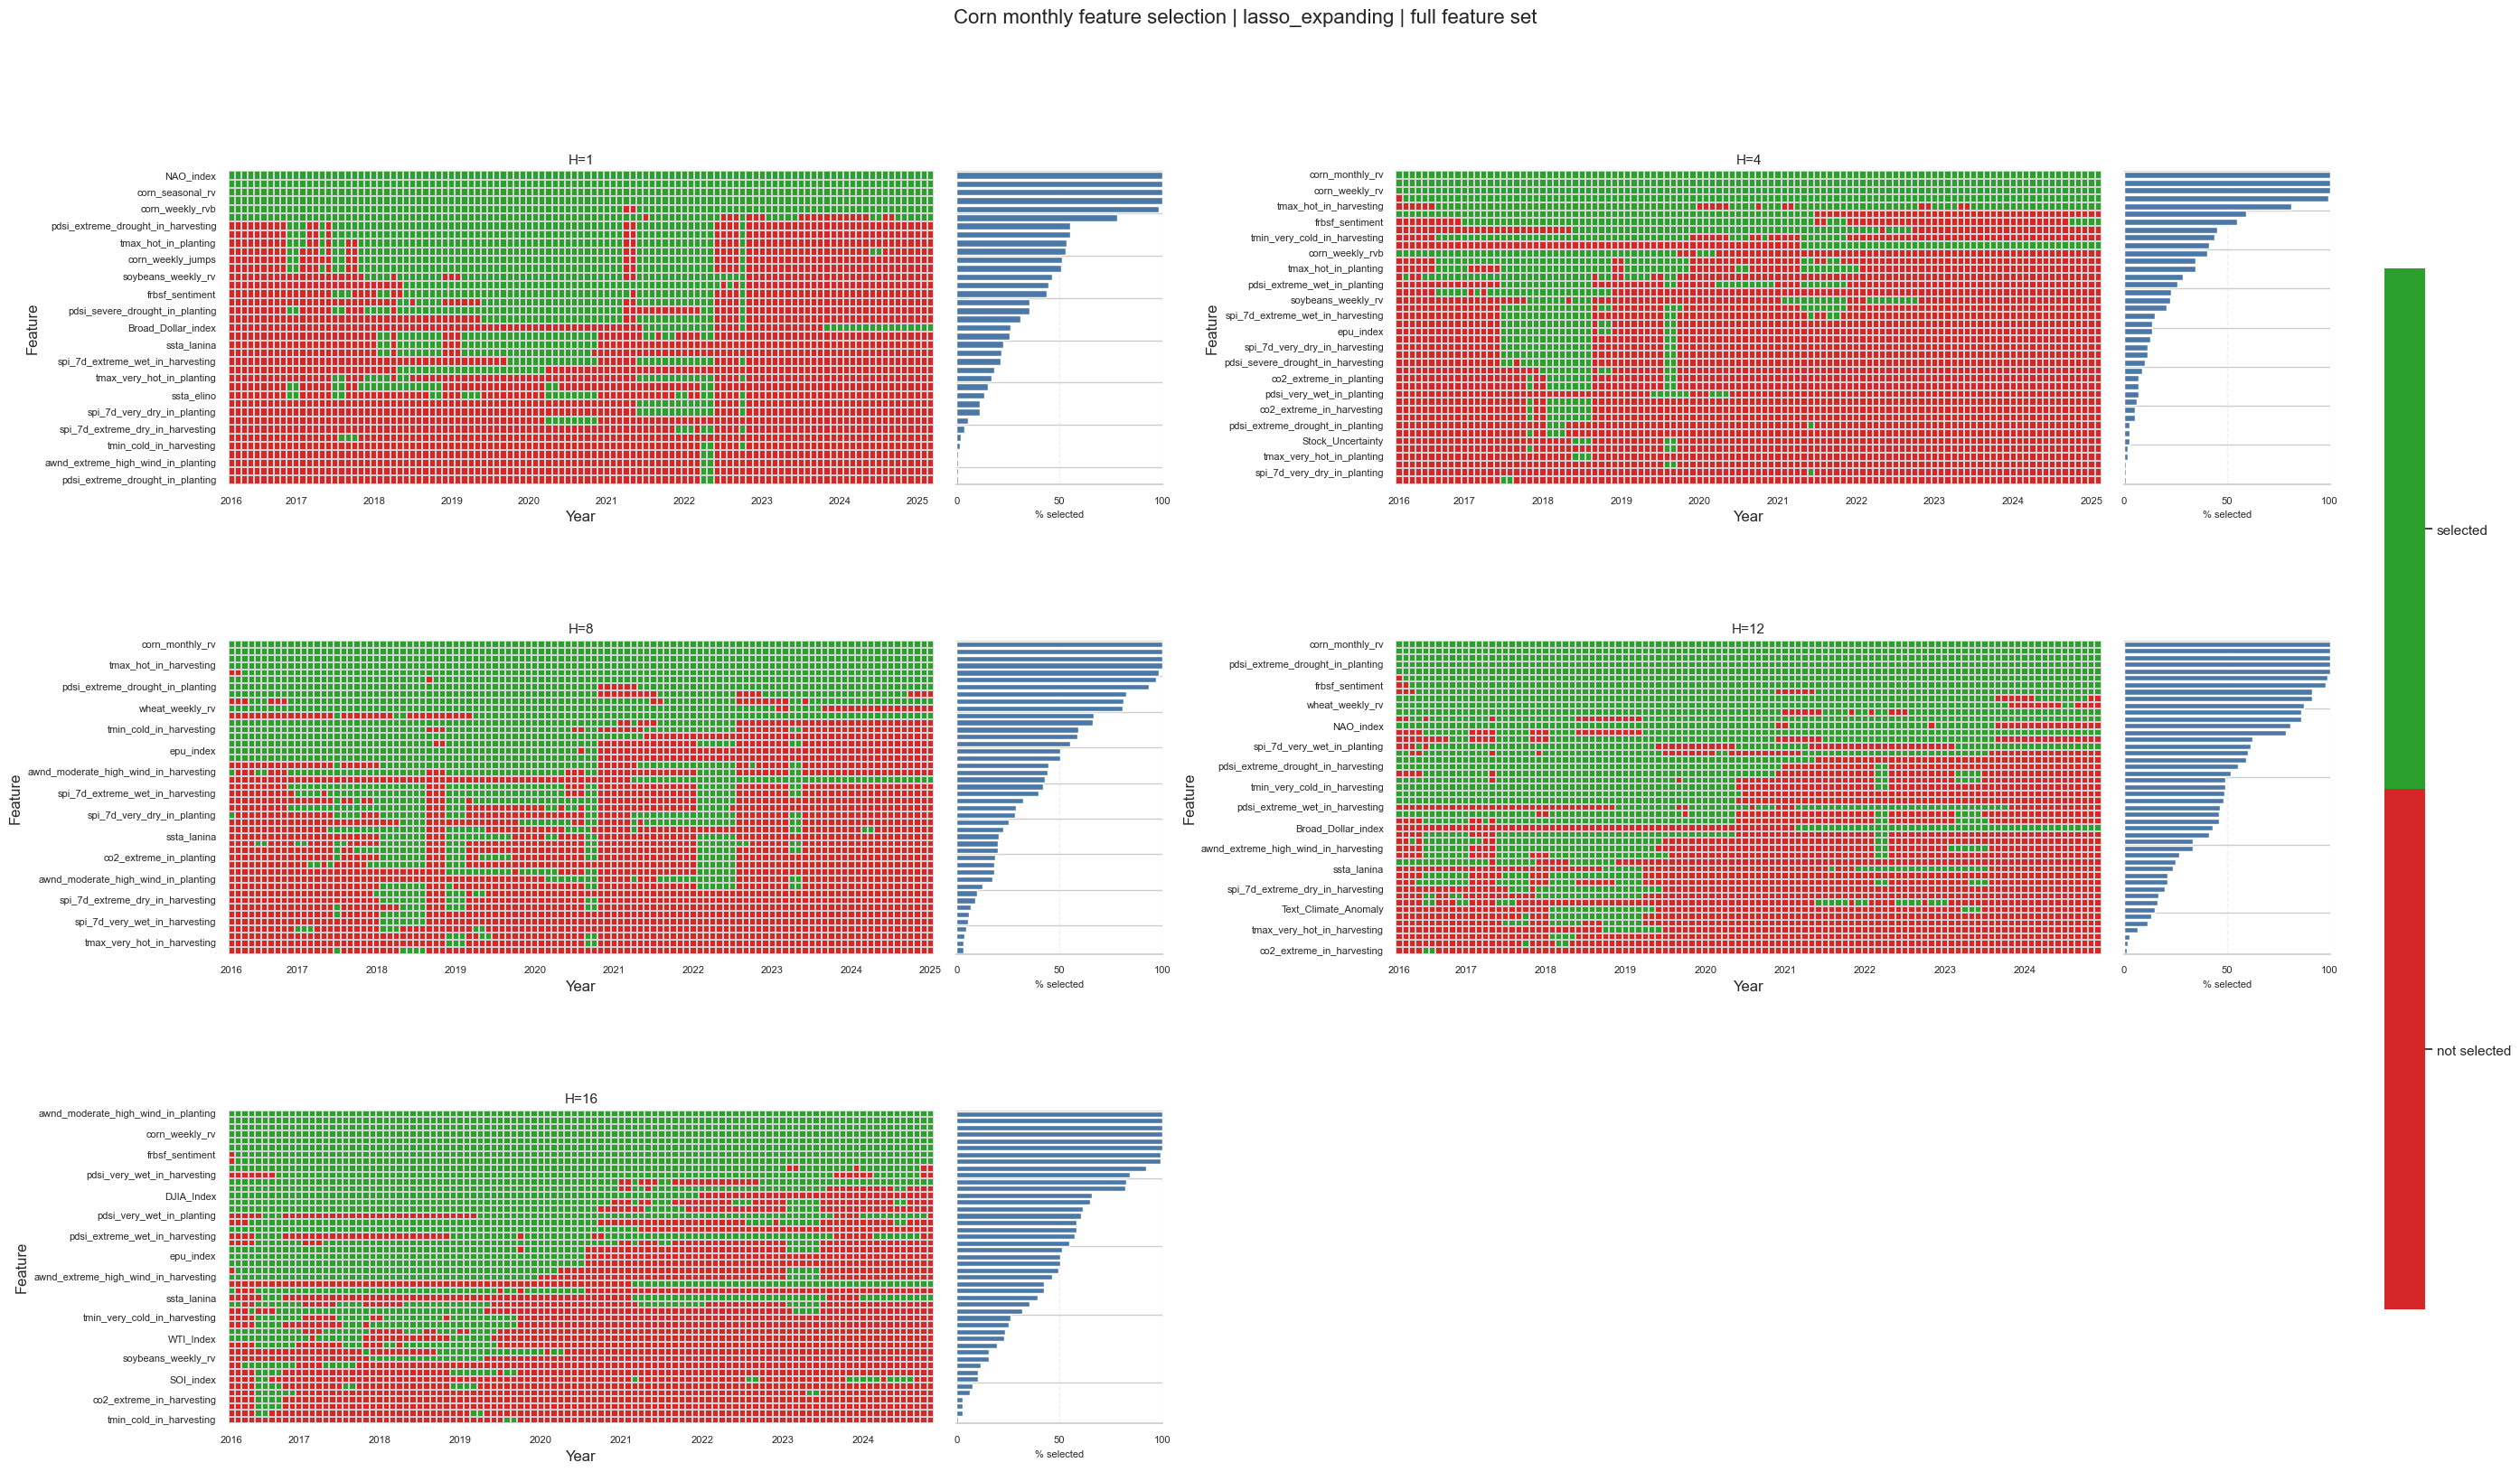

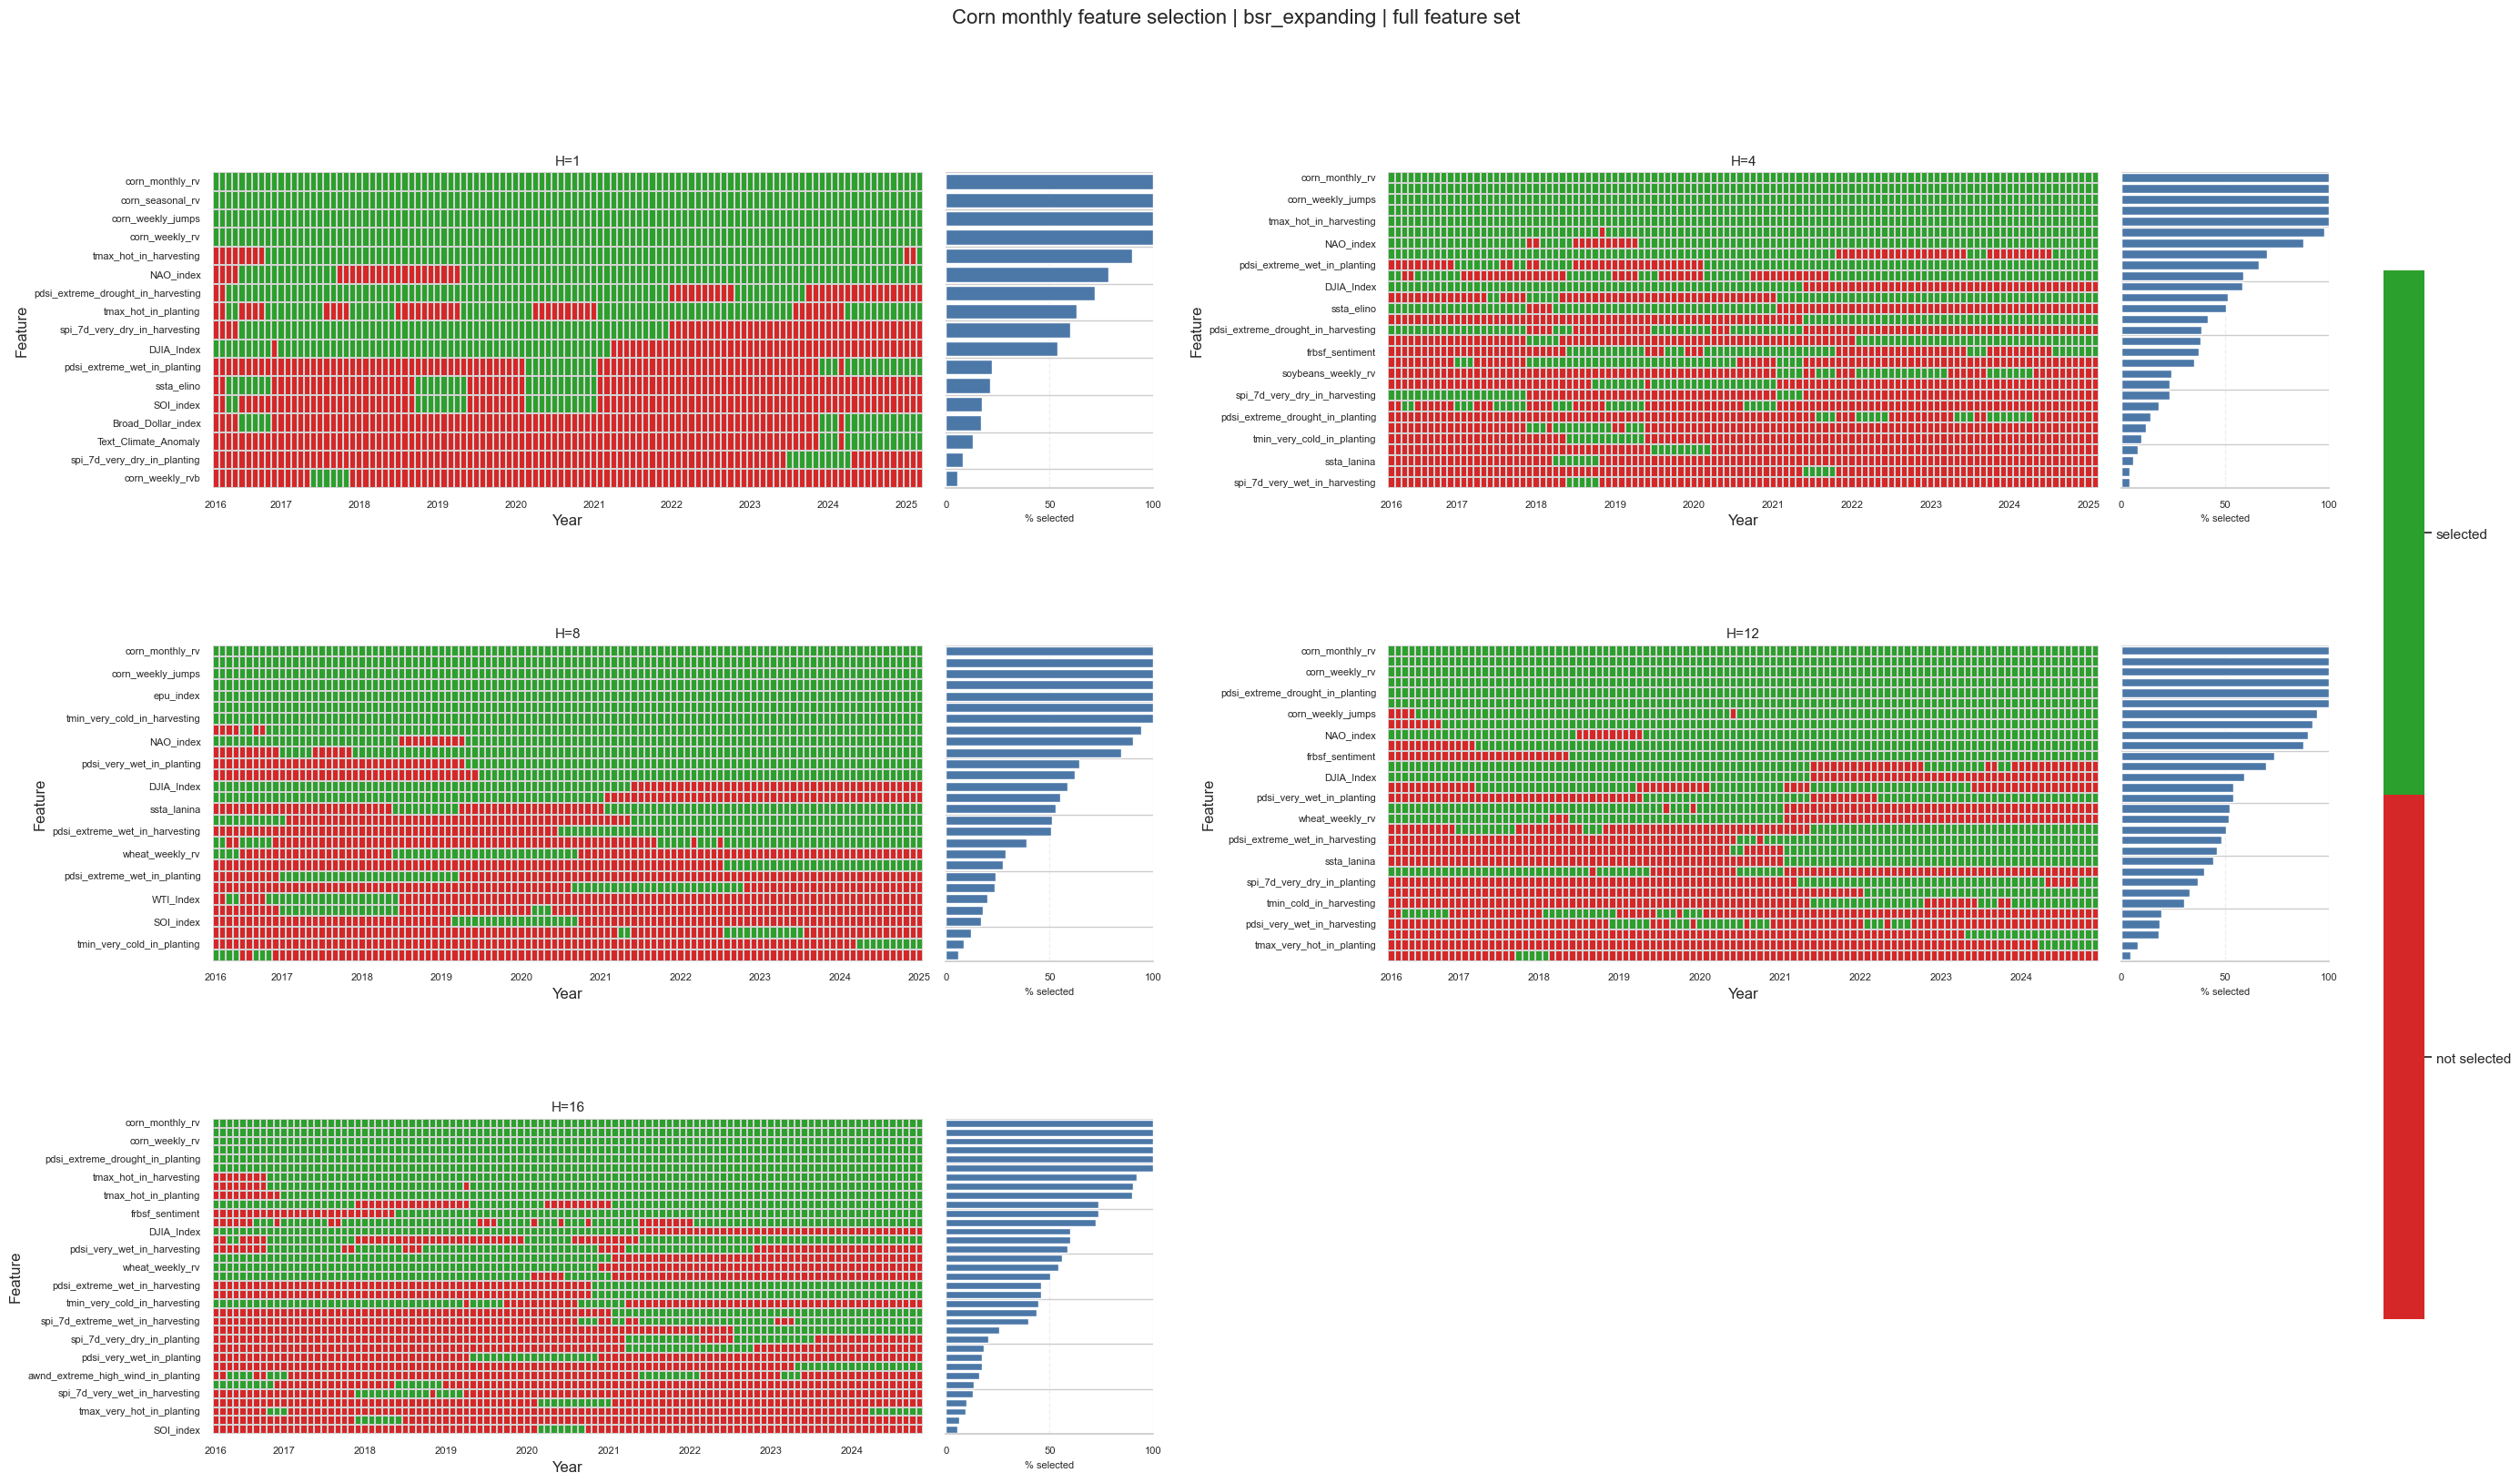

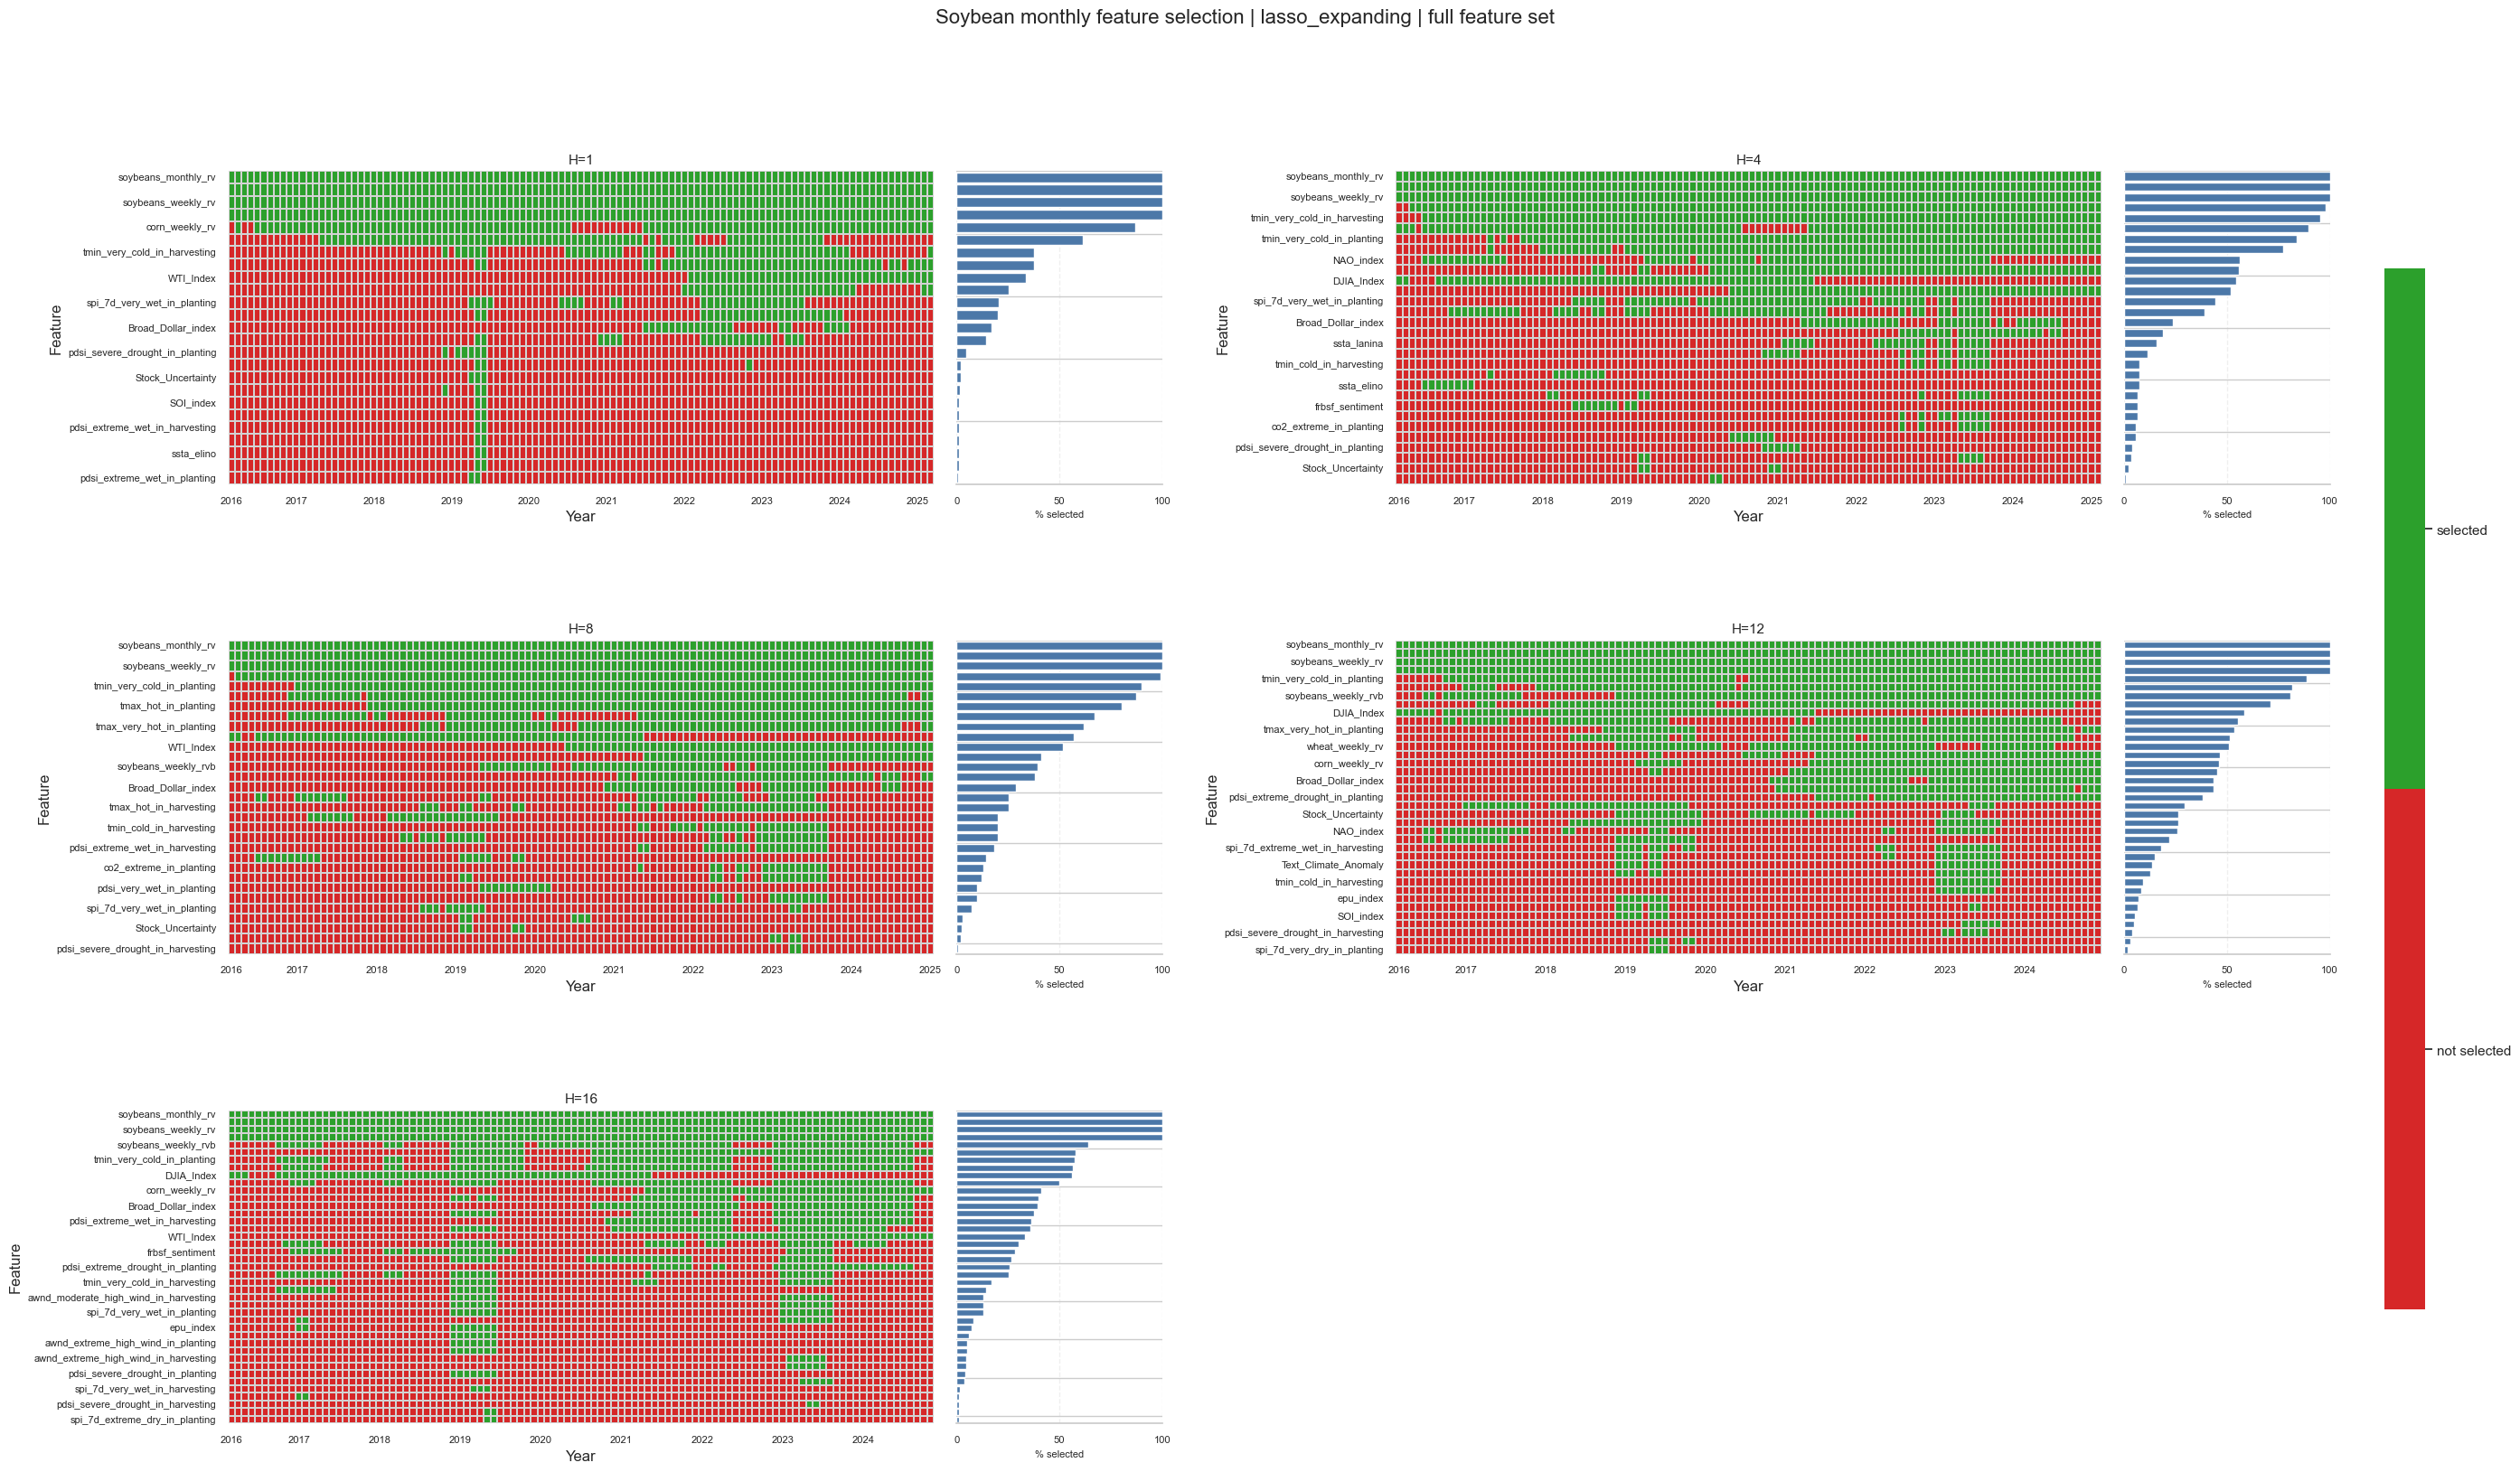

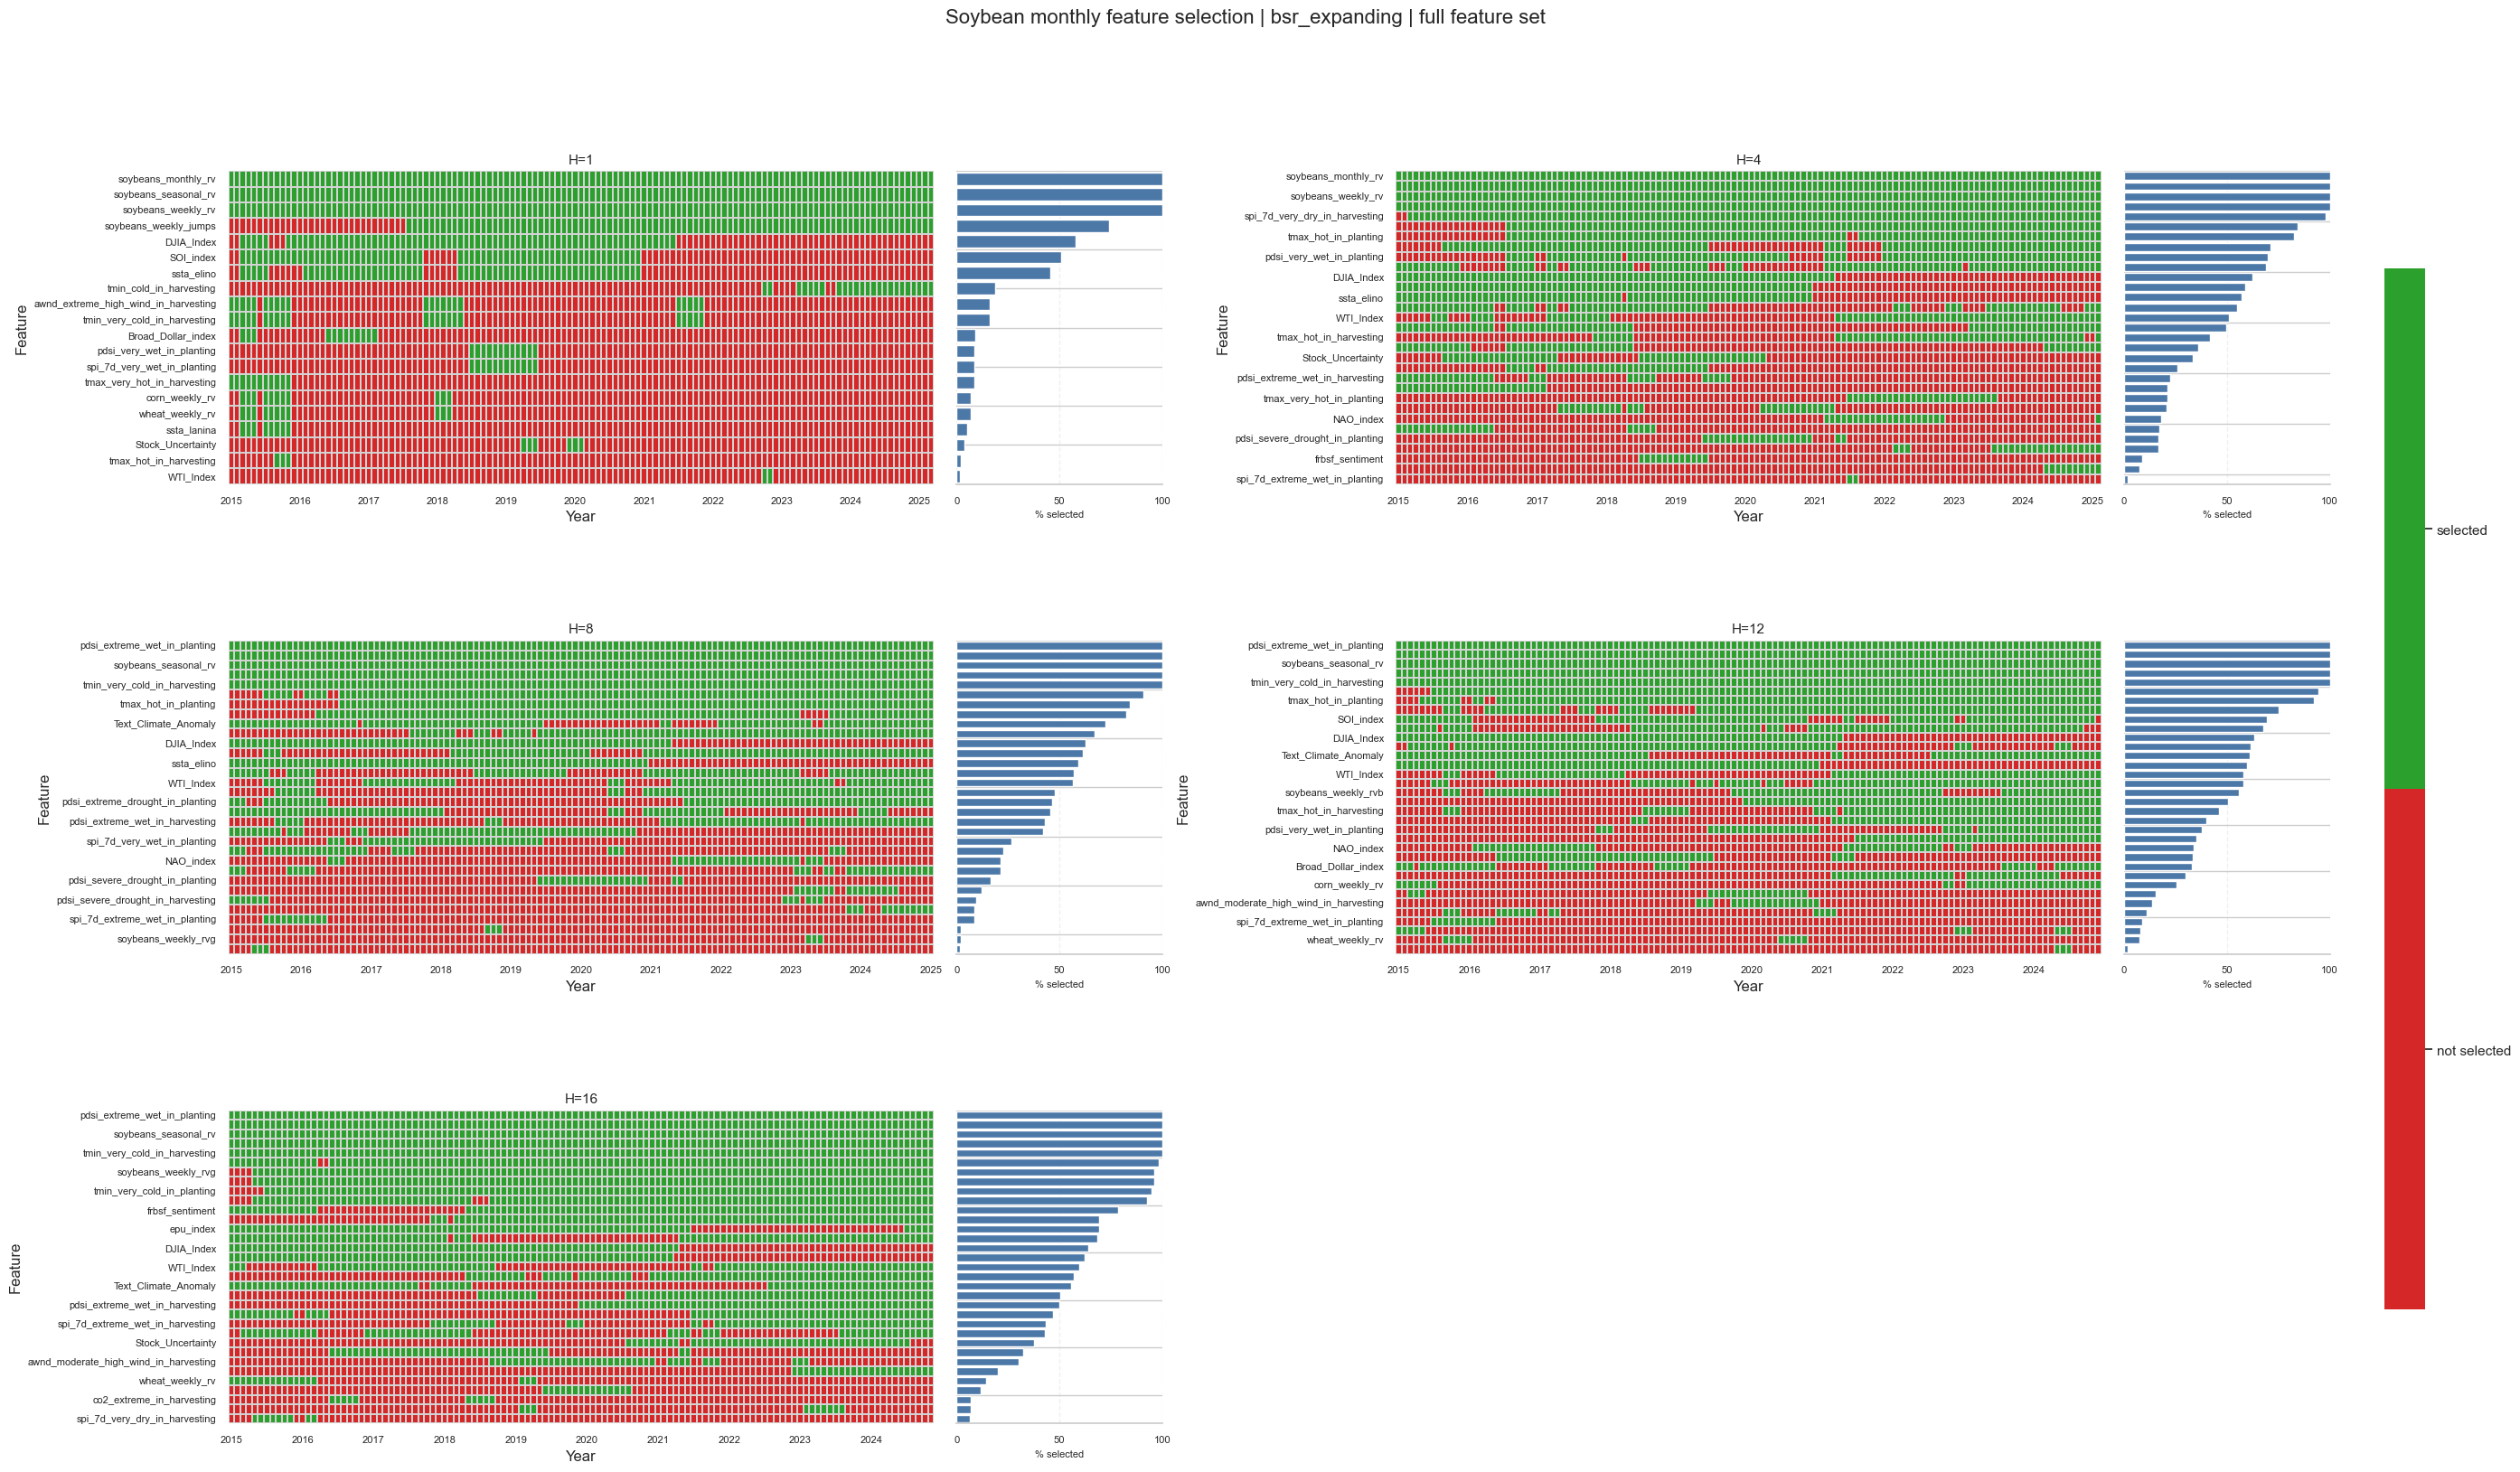

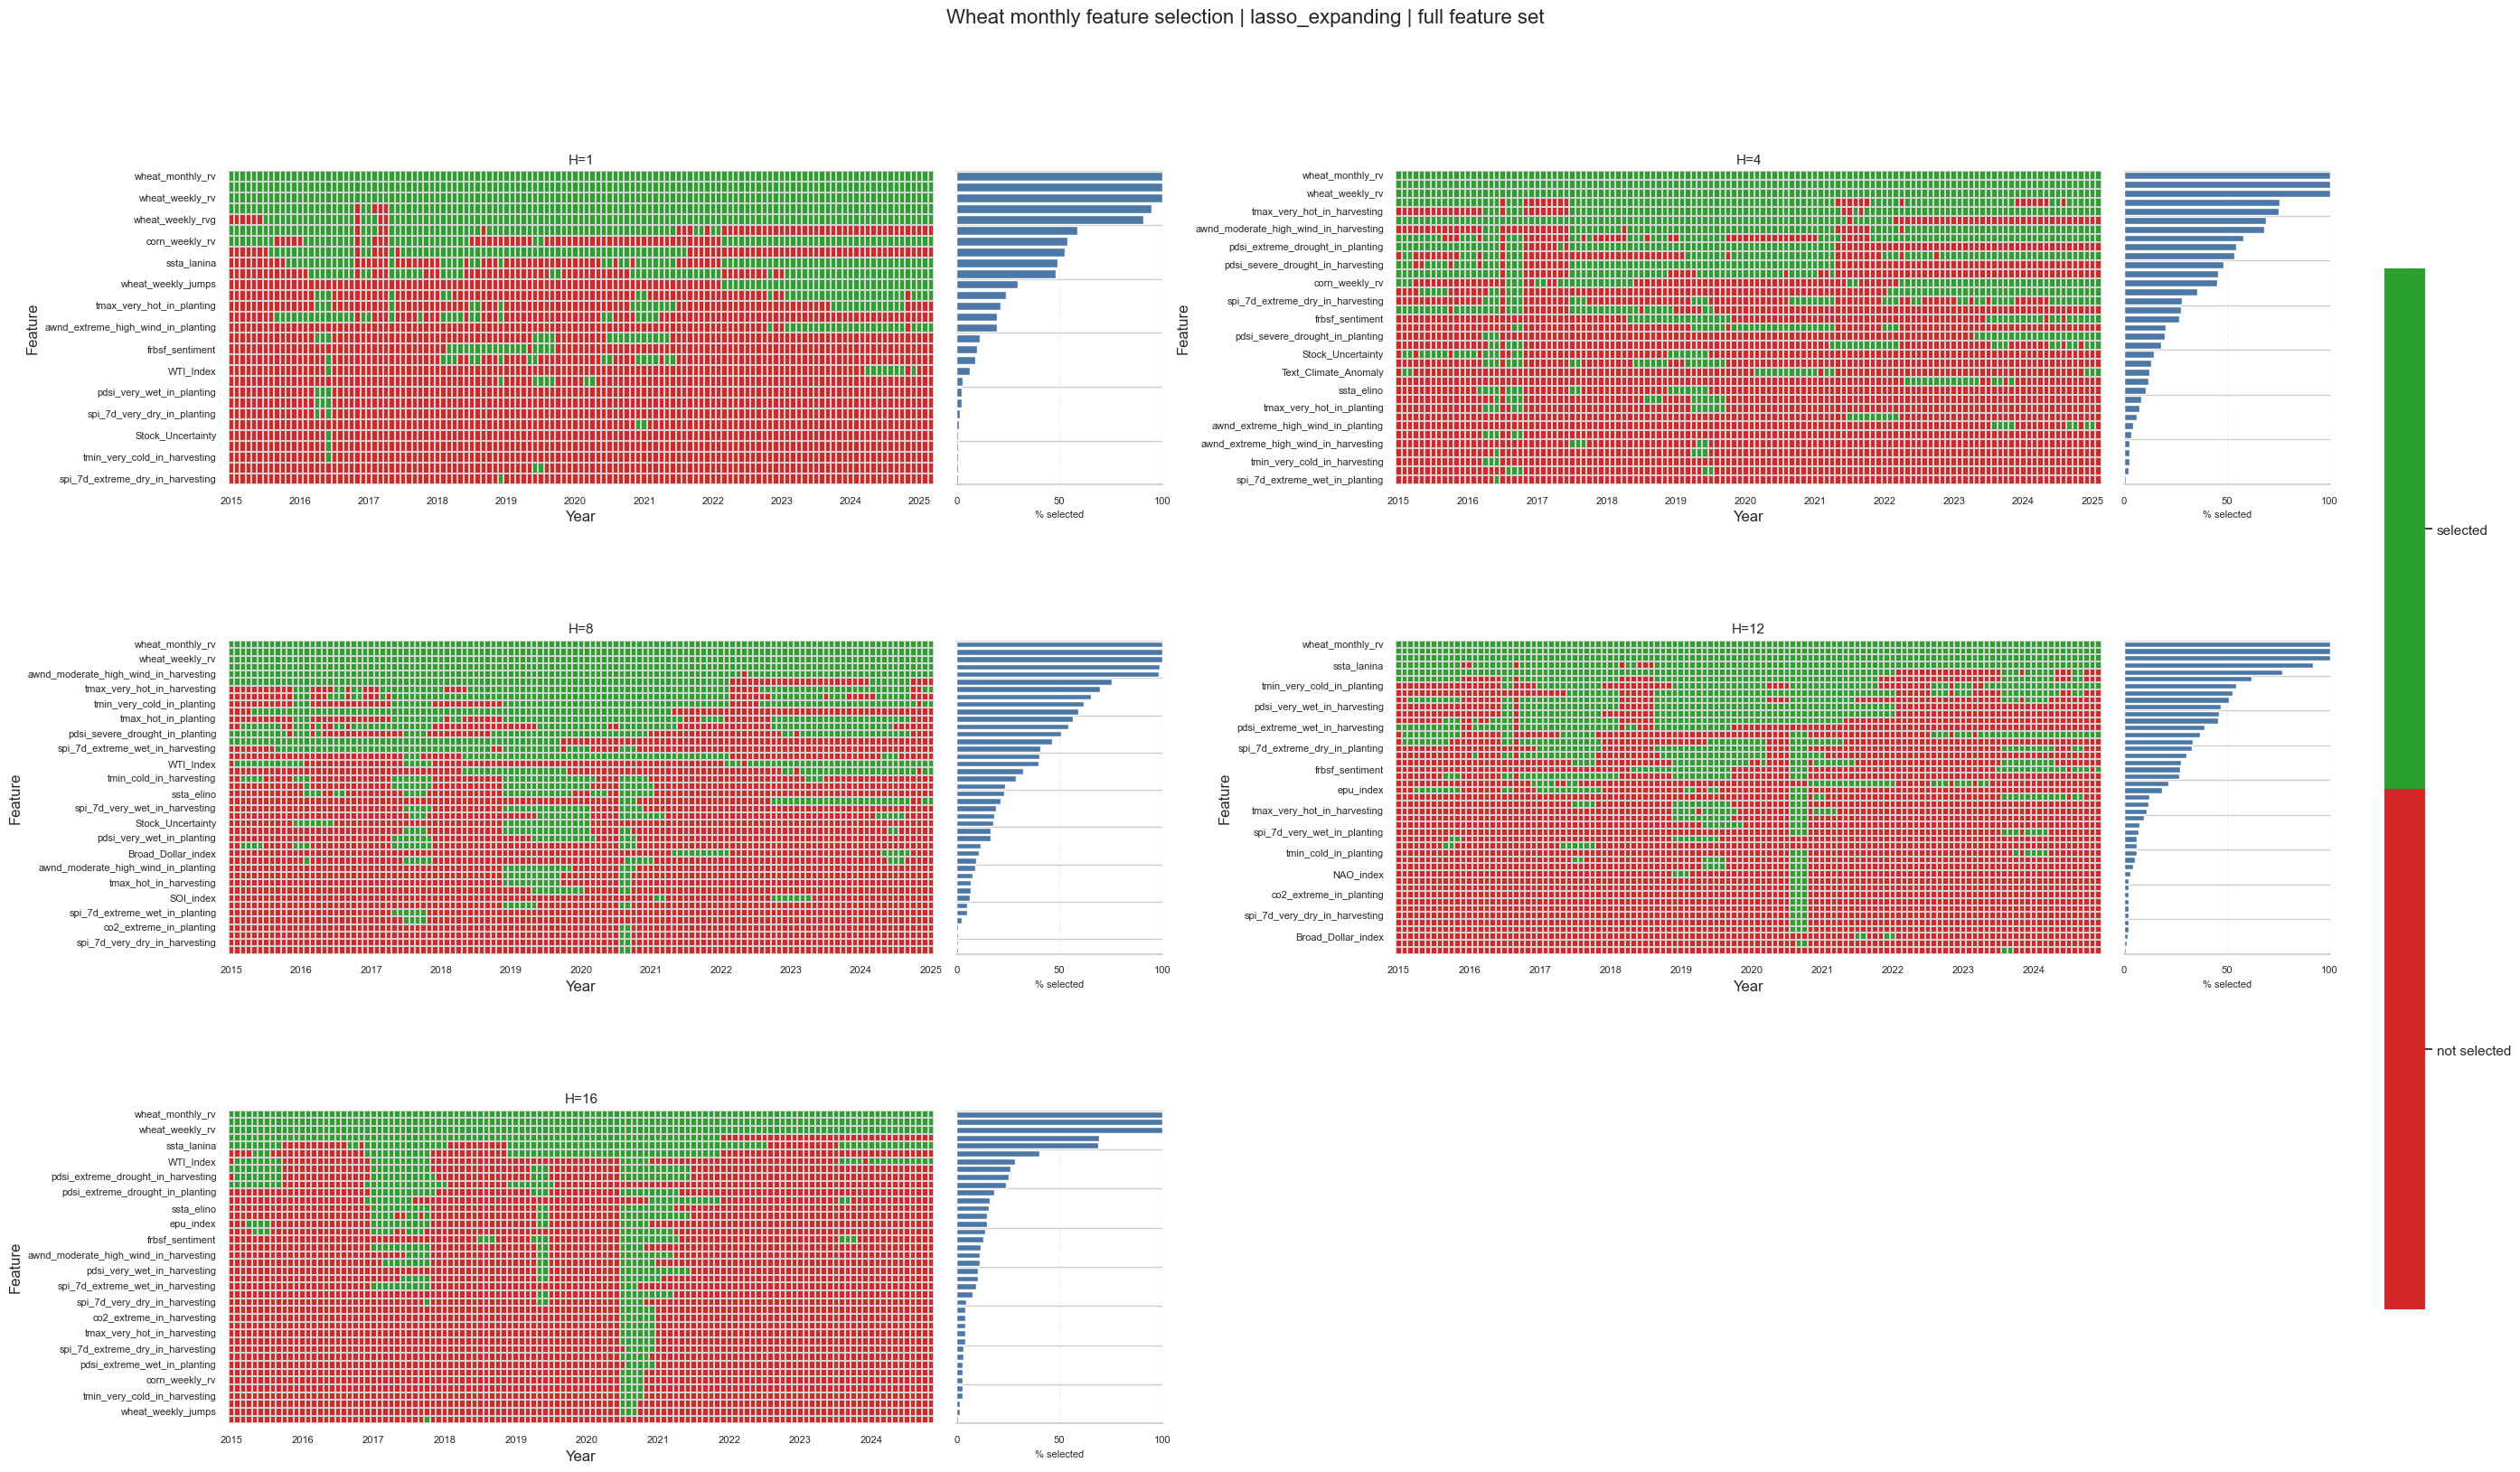

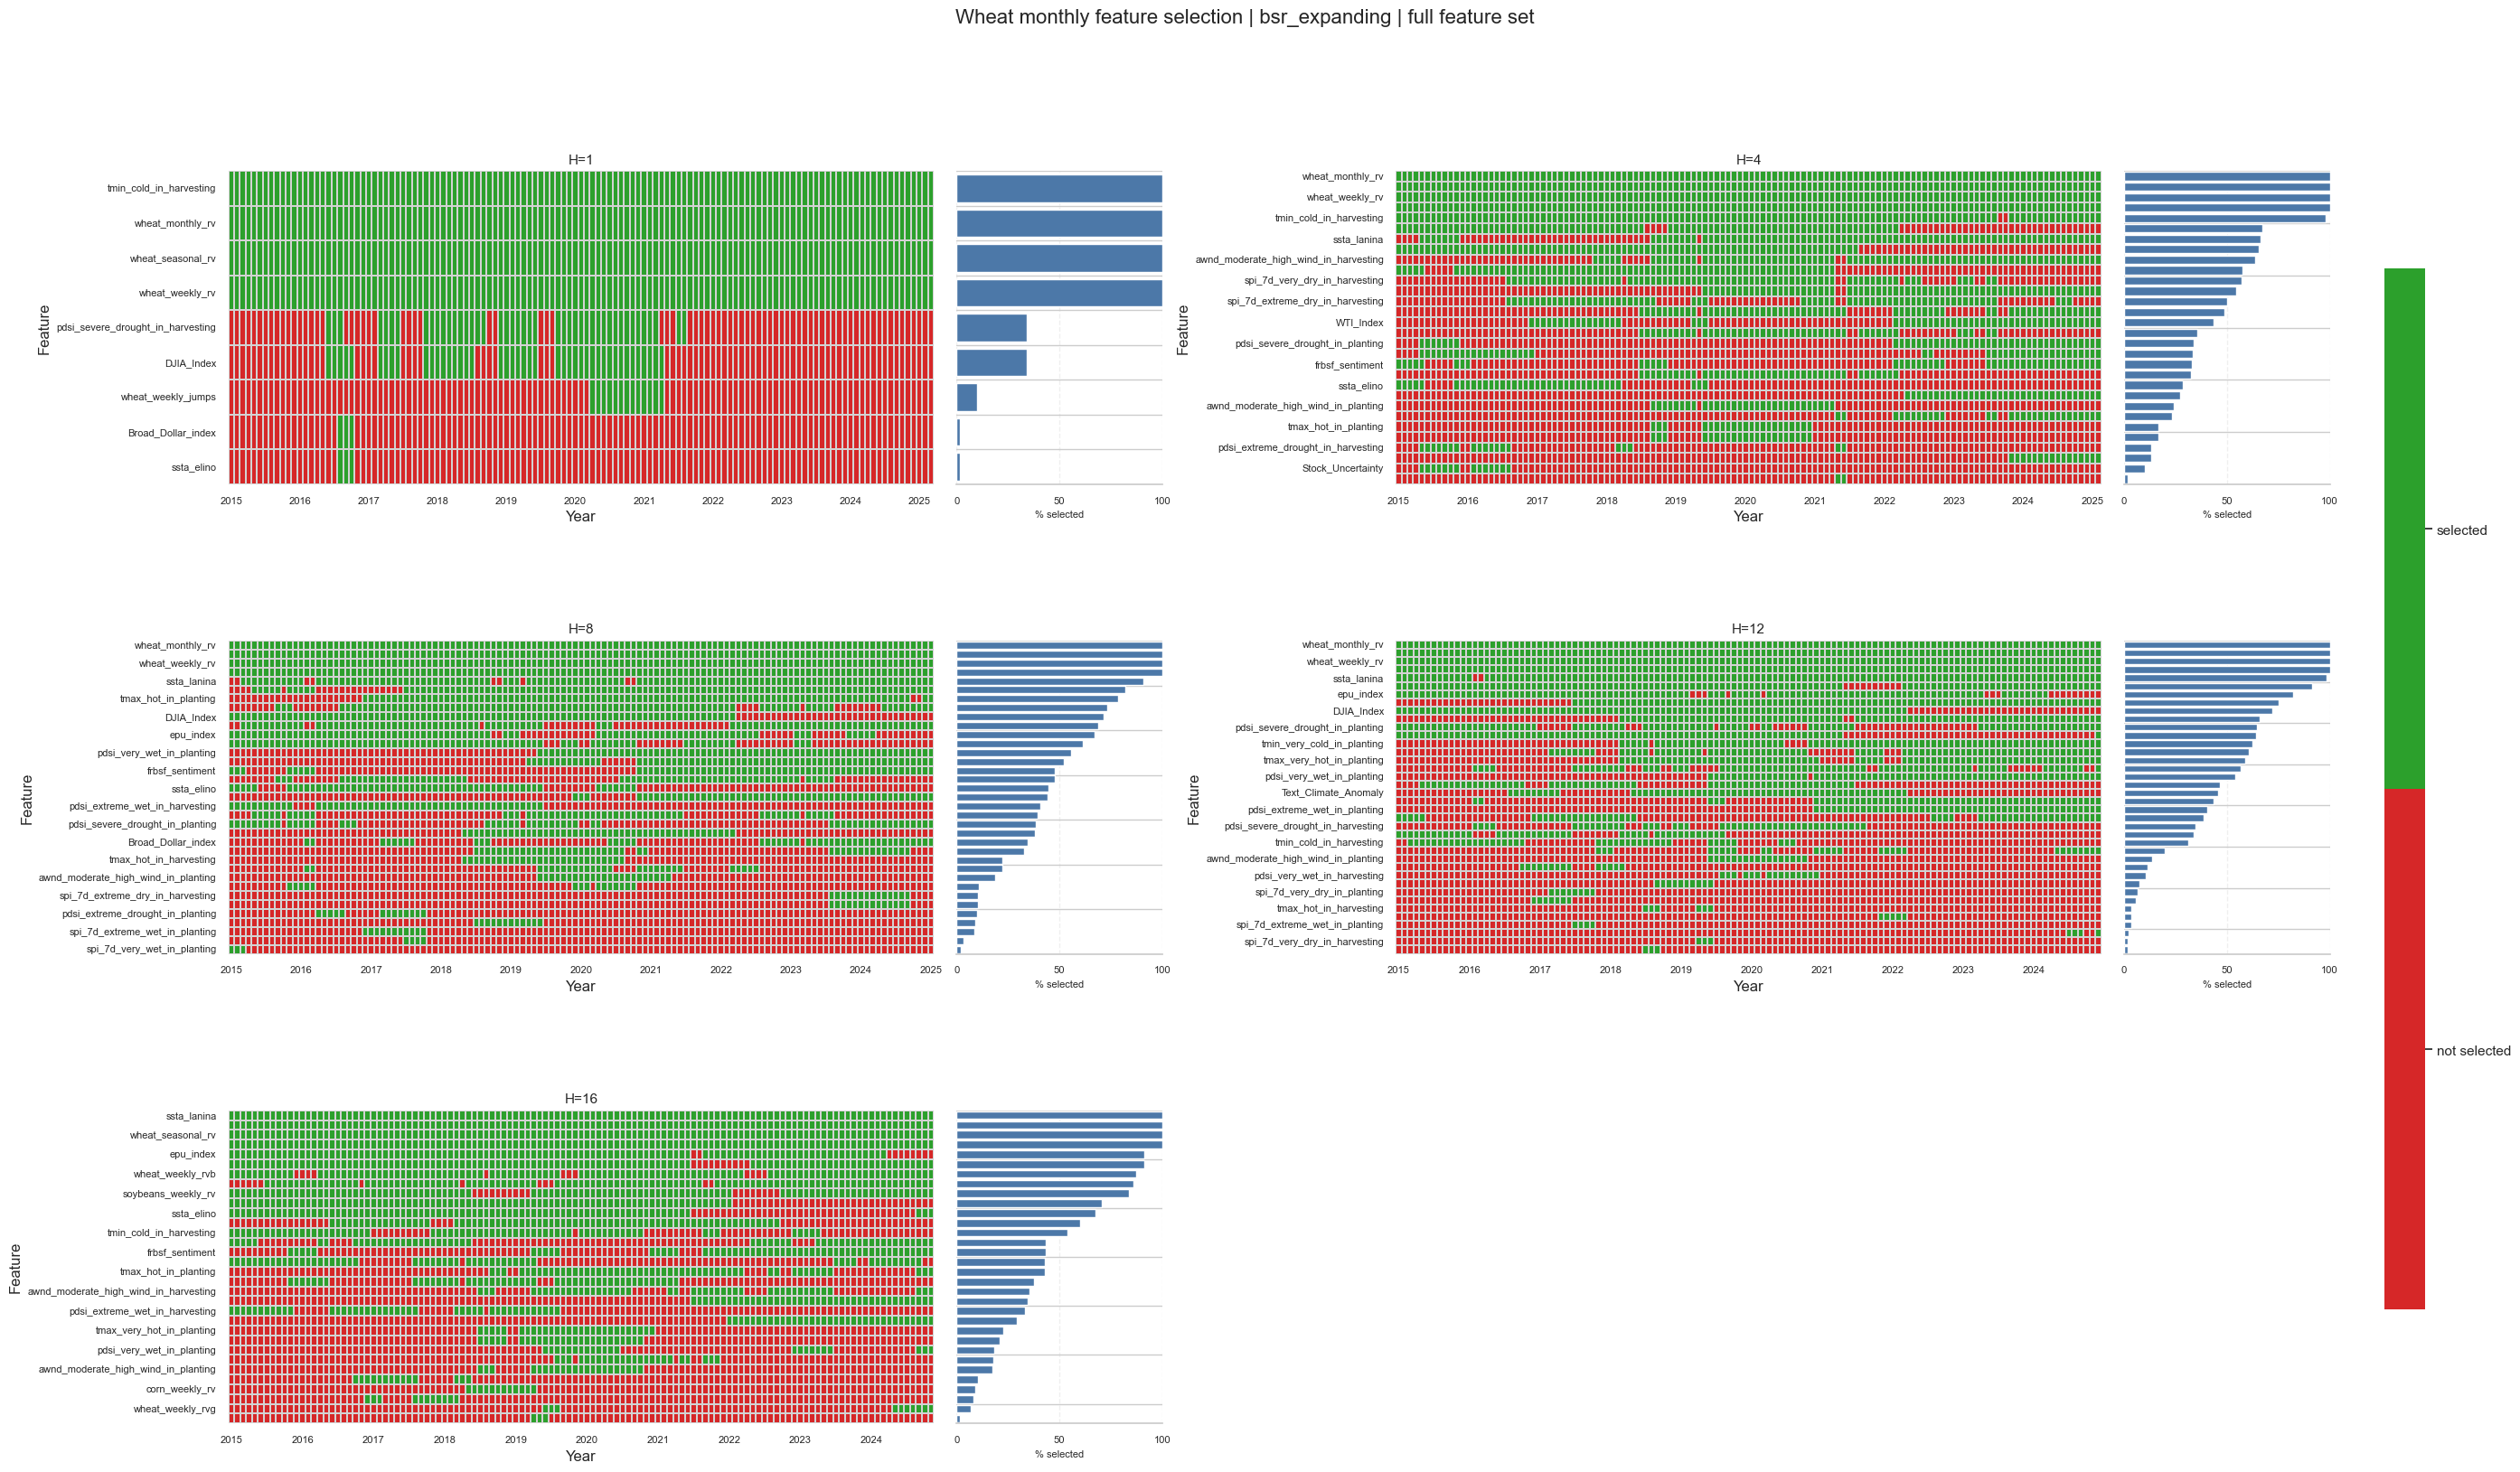

,crop,model_type,n_horizons,plot_path
0,corn,bsr_expanding,5,/Users/arshia/Projects/Papers/FinancialAI/Volf...
1,corn,lasso_expanding,5,/Users/arshia/Projects/Papers/FinancialAI/Volf...
2,soybean,bsr_expanding,5,/Users/arshia/Projects/Papers/FinancialAI/Volf...
3,soybean,lasso_expanding,5,/Users/arshia/Projects/Papers/FinancialAI/Volf...
4,wheat,bsr_expanding,5,/Users/arshia/Projects/Papers/FinancialAI/Volf...
5,wheat,lasso_expanding,5,/Users/arshia/Projects/Papers/FinancialAI/Volf...


In [8]:
plot_results: list[dict] = []

for crop in sorted(runs_to_process['crop'].unique()):
    for model_type in TARGET_MODEL_TYPES:
        pair_runs_df = runs_to_process.loc[
            runs_to_process['crop'].eq(crop) & runs_to_process['model_type'].eq(model_type)
        ].copy()
        if pair_runs_df.empty:
            continue

        output_path = OUTPUT_ROOT / crop / f'{crop}_{model_type}_feature_selection_monthly_grid.png'
        plot_crop_horizon_grid(
            pair_runs_df,
            monthly_lookup,
            crop=crop,
            model_type=model_type,
            output_path=output_path if SAVE_PLOTS else None,
            top_n_features=TOP_N_FEATURES,
        )
        plot_results.append(
            {
                'crop': crop,
                'model_type': model_type,
                'n_horizons': int(pair_runs_df['target_horizon'].nunique()),
                'plot_path': str(output_path) if SAVE_PLOTS else None,
            }
        )

results_df = pd.DataFrame(plot_results).sort_values(['crop', 'model_type']).reset_index(drop=True)
display(results_df)


In [9]:
manifest_path = OUTPUT_ROOT / 'feature_selection_monthly_model_crop_grid_manifest.csv'
results_df.to_csv(manifest_path, index=False)
print(f'Saved manifest: {manifest_path}')


Saved manifest: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/feature_selection_monthly/feature_selection_monthly_model_crop_grid_manifest.csv


## Output files

The notebook saves **6 total plots**: one **2 x 3** horizon-grid plot for each `(crop, model_type)` pair:
- `data/benchmark/plots/feature_selection_monthly/wheat/wheat_lasso_expanding_feature_selection_monthly_grid.png`
- `data/benchmark/plots/feature_selection_monthly/wheat/wheat_bsr_expanding_feature_selection_monthly_grid.png`
- `data/benchmark/plots/feature_selection_monthly/corn/corn_lasso_expanding_feature_selection_monthly_grid.png`
- `data/benchmark/plots/feature_selection_monthly/corn/corn_bsr_expanding_feature_selection_monthly_grid.png`
- `data/benchmark/plots/feature_selection_monthly/soybean/soybean_lasso_expanding_feature_selection_monthly_grid.png`
- `data/benchmark/plots/feature_selection_monthly/soybean/soybean_bsr_expanding_feature_selection_monthly_grid.png`

It also saves one manifest:
- `data/benchmark/plots/feature_selection_monthly/feature_selection_monthly_model_crop_grid_manifest.csv`
